In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("X shape:", X.shape)
print("Target:", data.target_names)
print("\nClass disturbution:")
print(y.value_counts().sort_index())
print("\nClass proportions:")
print(y.value_counts(normalize=True).sort_index())

X shape: (569, 30)
Target: ['malignant' 'benign']

Class disturbution:
target
0    212
1    357
Name: count, dtype: int64

Class proportions:
target
0    0.372583
1    0.627417
Name: proportion, dtype: float64


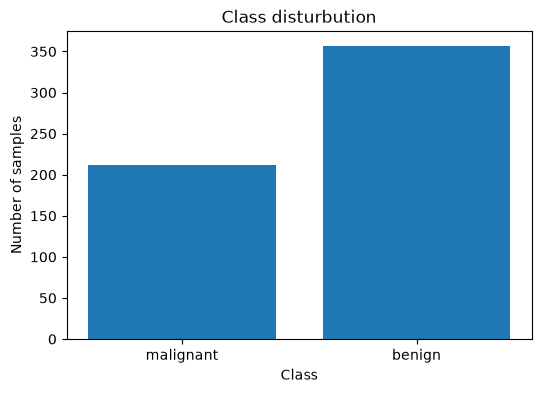

In [3]:
class_counts = y.value_counts().sort_index()
labels = [data.target_names[i] for i in class_counts.index]

plt.figure(figsize=(6,4))
plt.bar(labels, class_counts.values)
plt.title("Class disturbution")
plt.ylabel("Number of samples")
plt.xlabel("Class")
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (455, 30)
Test: (114, 30)


In [5]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_train_score = dt.score(X_train, y_train)
dt_cv_score = cross_val_score(dt, X_train, y_train, cv=cv, scoring="accuracy")

print("Decision Tree training accuracy:", round(dt_train_score, 4))
print("Decision Tree CV mean:", np.round(dt_cv_score, 4))
print("Decision Tree OOB score:", round(dt_cv_score.mean(), 4))

Decision Tree training accuracy: 1.0
Decision Tree CV mean: [0.9341 0.9341 0.9011 0.8901 0.9231]
Decision Tree OOB score: 0.9165


In [6]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_score = rf.score(X_train, y_train)
rf_cv_score = cross_val_score(rf, X_train, y_train, cv=cv, scoring="accuracy")

print("Random Forest training accuracy:", round(rf_train_score, 4))
print("Random Forest CV mean:", np.round(rf_cv_score, 4))
print("Random Forest OOB score:", round(rf_cv_score.mean(), 4))

Random Forest training accuracy: 1.0
Random Forest CV mean: [0.967  0.956  0.9341 0.967  0.989 ]
Random Forest OOB score: 0.9626


In [7]:
tree_counts = [1, 10, 100]
exp_a = []

for n in tree_counts:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )   
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    model.fit(X_train, y_train)
    exp_a.append({
        "n_estimators":n,
        "cv_mean":scores.mean(),
        "cv_std":scores.std(),
        "train_score":model.score(X_train, y_train)
    })


exp_a_df = pd.DataFrame(exp_a)
exp_a_df    


,n_estimators,cv_mean,cv_std,train_score
0,1,0.925275,0.014579,0.971429
1,10,0.956044,0.015541,0.995604
2,100,0.962637,0.017855,1.000000


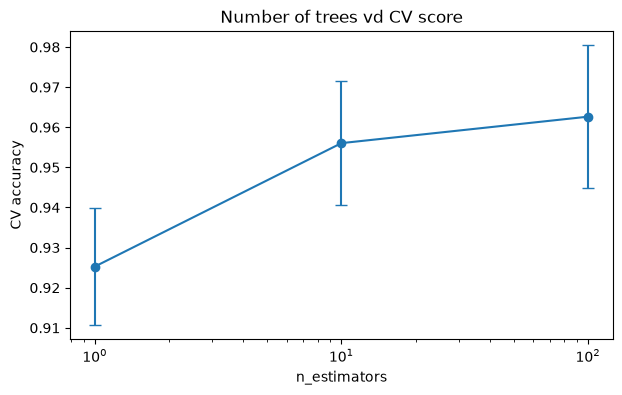

In [8]:
plt.figure(figsize=(7,4))
plt.errorbar(
    exp_a_df["n_estimators"],
    exp_a_df["cv_mean"],
    yerr=exp_a_df["cv_std"],
    marker="o",
    capsize=4
)
plt.xscale("log")
plt.xlabel("n_estimators")
plt.ylabel("CV accuracy")
plt.title("Number of trees vd CV score")
plt.show()

In [9]:
depths = [2,3,5,8,12,None]
exp_b = []

for depth in depths:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    model.fit(X_train, y_train)
    exp_b.append({
        "max_depth":"None" if depth is None else depth,
        "cv_mean":scores.mean(),
        "cv_std":scores.std(),
        "train_score":model.score(X_train, y_train)
    })

exp_b_df = pd.DataFrame(exp_b)
exp_b_df

,max_depth,cv_mean,cv_std,train_score
0,2,0.953846,0.014579,0.964835
1,3,0.953846,0.014579,0.980220
2,5,0.960440,0.017855,0.993407
3,8,0.964835,0.017582,1.000000
4,12,0.962637,0.017855,1.000000
5,None,0.962637,0.017855,1.000000


In [10]:
feature_options = ["sqrt", "log2", None]
exp_c = []
for mf in feature_options:
    model = RandomForestClassifier(
        n_estimators=100,
        max_features=mf,
        random_state=42,
        n_jobs=-1
    )
    scores=cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    exp_c.append({
        "max_features":str(mf),
        "cv_mean":scores.mean(),
        "cv_std":scores.std()
    })

exp_c_df = pd.DataFrame(exp_c)
exp_c_df

,max_features,cv_mean,cv_std
0,sqrt,0.962637,0.017855
1,log2,0.964835,0.018906
2,None,0.953846,0.018906


In [11]:
split_values = [2, 5, 10, 20]
exp_split = []

for mss in split_values:
    model = RandomForestClassifier(
        n_estimators=100,
        min_samples_split=mss,
        random_state=42,
        n_jobs=-1
    )
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    model.fit(X_train, y_train)
    exp_split.append({
        "min_samples_split":mss,
        "cv_mean": scores.mean(),
        "cv_std": scores.std(),
        "train_score": model.score(X_train, y_train)
    })

pd.DataFrame(exp_split)

,min_samples_split,cv_mean,cv_std,train_score
0,2,0.962637,0.017855,1.000000
1,5,0.958242,0.016150,0.995604
2,10,0.951648,0.011207,0.993407
3,20,0.951648,0.013187,0.984615
